In [1]:
import tensorflow as tf

# Desactivar GPU completamente
tf.config.set_visible_devices([], 'GPU')

print("Devices:", tf.config.list_physical_devices())

I0000 00:00:1773112575.460643   42958 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773112575.490187   42958 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773112576.519007   42958 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
# Importing the libraries

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU
from keras.optimizers import SGD
from keras import activations
import math
from sklearn.metrics import mean_squared_error

In [3]:
# get the data
path_file = "DataSets/AMZN_2006-01-01_to_2018-01-01.csv"
dataset1 = pd.read_csv(path_file, index_col='Date', parse_dates=['Date'])
dataset1.head()  

dataset = dataset1.dropna()  # Eliminar cualquier fila con NaN en cualquier columna

training_set = dataset.loc[:'2016', ["Low"]].values  # modificar dependiendo de la tarea
test_set = dataset.loc['2017':, ["Low"]].values   # modificar dependiendo de la tarea


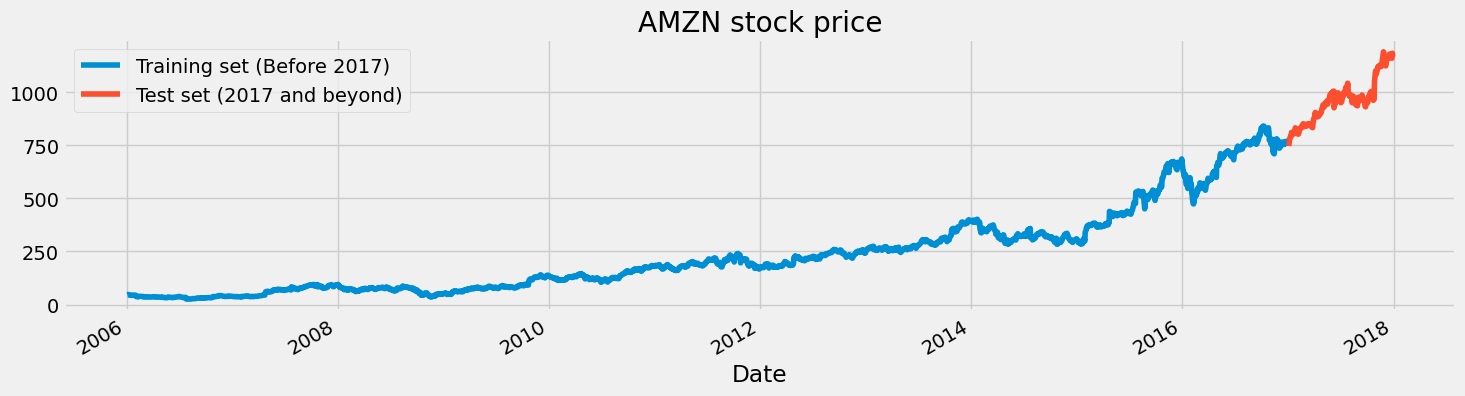

In [4]:
# We have chosen 'Low' attribute for prices. Let's see what it looks like
dataset["Low"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["Low"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('AMZN stock price')
plt.show()

In [5]:
# Scaling the training set
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

# we create a data structure with 60 timesteps and 1 output
# So for each element of training set, we have 60 previous training set elements 
X_train = []
y_train = []
previous_days = 30  # cantidad de días previos usados para la predicción
N = training_set.shape[0]

for i in range(previous_days,N):
    X_train.append(training_set_scaled[i-previous_days:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [6]:
# Reshaping X_train 
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],1))    

In [7]:
# The LSTM architecture
regressor = Sequential()
# First LSTM layer with Dropout regularisation
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2))
# Second LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Third LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Fourth LSTM layer
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
# The output layer
regressor.add(Dense(units=1, activation='linear'))

# Compiling the RNN
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')
regressor.summary()

/home/sergioai/miniconda3/envs/ml/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Fitting to the training set
regressor.fit(X_train,y_train,epochs=10,batch_size=32)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0090
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0039
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0032
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0027
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0026 
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0022
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0022
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0020
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0016  
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0017


In [9]:
# get the test set ready in a similar way as the training set.
dataset_total = pd.concat((dataset["Low"][:'2016'],dataset["Low"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - previous_days:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

# Preparing X_test and predicting the prices
X_test = []
N1 = inputs.shape[0]
for i in range(previous_days,N1):
    X_test.append(inputs[i-previous_days:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))

In [10]:
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


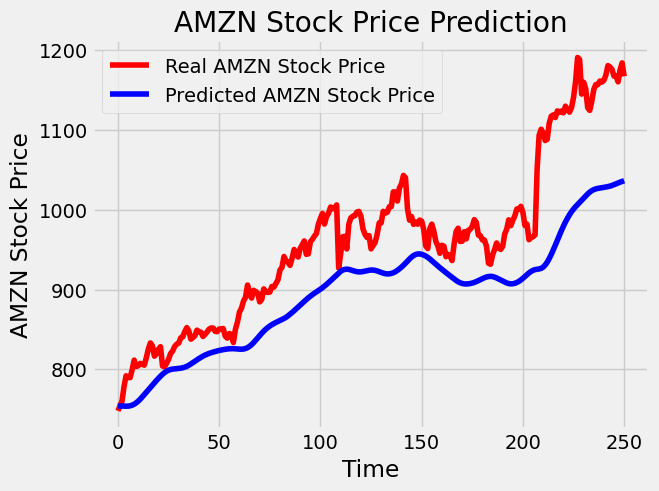

The root mean squared error is 79.059776430659.


In [11]:
plt.plot(test_set, color='red',label='Real AMZN Stock Price')
plt.plot(predicted_stock_price, color='blue',label='Predicted AMZN Stock Price')
plt.title('AMZN Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('AMZN Stock Price')
plt.legend()
plt.show()
# Evaluating our model
rmse = math.sqrt(mean_squared_error(test_set, predicted_stock_price))
print("The root mean squared error is {}.".format(rmse))

In [12]:
---------------------------------------------------------------------------
lib/python3.10/site-packages/keras/src/layers/rnn/lstm.py:476, in LSTM.__init__(self, units, activation, recurrent_activation, use_bias, kernel_initializer, recurrent_initializer, bias_initializer, unit_forget_bias, kernel_regularizer, recurrent_regularizer, bias_regularizer, activity_regularizer, kernel_constraint, recurrent_constraint, bias_constraint, dropout, recurrent_dropout, seed, return_sequences, return_state, go_backwards, stateful, unroll, use_cudnn, **kwargs)
    448 def __init__(
    449     self,
    450     units,InternalError                             Traceback (most recent call last)
Cell In[17], line 4
      2 regressor = Sequential()
      3 # First LSTM layer with Dropout regularisation
----> 4 regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
      5 regressor.add(Dropout(0.2))
      6 # Second LSTM layer

File ~/miniconda3/envs/ml/
   (...)
    474     **kwargs,
    475 ):
--> 476     cell = LSTMCell(
    477         units,
    478         activation=activation,
    479         recurrent_activation=recurrent_activation,
    480         use_bias=use_bias,
    481         kernel_initializer=kernel_initializer,
    482         unit_forget_bias=unit_forget_bias,
    483         recurrent_initializer=recurrent_initializer,
    484         bias_initializer=bias_initializer,
...
--> 152         return tf.cast(x, dtype)
    153     return tf.convert_to_tensor(x, dtype=dtype)
    154 elif dtype is not None and not standardize_dtype(x.dtype) == dtype:

InternalError: {{function_node __wrapped__Cast_device_/job:localhost/replica:0/task:0/device:GPU:0}} 'cuLaunchKernel(function, gridX, gridY, gridZ, blockX, blockY, blockZ, 0, reinterpret_cast<CUstream>(stream), params, nullptr)' failed with 'CUDA_ERROR_INVALID_HANDLE' [Op:Cast] name: 
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

SyntaxError: invalid syntax (916714903.py, line 1)